# House Prices - Advanced Regression Techniques

# Loading Dataset

In [1]:
import pandas as pd

In [35]:
df = pd.read_csv(r"C:\Users\gs602\Downloads\train.csv")

In [36]:
df


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


# Exploratory Data Analysis(EDA)

In [12]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,22.024023,9981.264932,1.382997,1.112799,30.202904,20.645407,180.569112,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,70.049958,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [11]:
df.isnull().sum()

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
OverallQual              0
                        ..
SaleCondition_AdjLand    0
SaleCondition_Alloca     0
SaleCondition_Family     0
SaleCondition_Normal     0
SaleCondition_Partial    0
Length: 231, dtype: int64

In [83]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1455    False
1456    False
1457    False
1458    False
1459    False
Length: 1460, dtype: bool

In [85]:
df.drop_duplicates(inplace = True)

# Data Cleaning

In [38]:
# Ensure df is a deep copy to avoid SettingWithCopyWarning
df = df.copy()

# 1. Drop columns with too many NaNs
df = df.dropna(axis=1, thresh=len(df)*0.6)

# 2. Fill numerical NaNs (Reassignment is safer than inplace=True)
df = df.fillna(df.mean(numeric_only=True))

# 3. Fill categorical NaNs using .loc
cat_cols = df.select_dtypes(include=['object']).columns
df.loc[:, cat_cols] = df[cat_cols].fillna('Unknown')

# 4. Convert to dummies
df = pd.get_dummies(df, drop_first=True)

# Defining Feature & Target

In [39]:
X = df.drop("SalePrice" , axis = 1)
y = df["SalePrice"]

In [40]:
print(X.shape)
print(y.shape)

(1460, 240)
(1460,)


# Train_Test_Split

In [53]:
from sklearn.model_selection import train_test_split

In [45]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 ,  random_state = 42)

In [42]:
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

1168 292
292 1168


# Model Training

In [21]:
from xgboost import XGBRegressor

In [46]:
model = XGBRegressor(n_estimators=500 , learning_rate = 0.05 , max_depth = 5 , random_state = 42)

In [47]:
model.fit(X_train , y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [48]:
y_pred = model.predict(X_test)

# Model Evaluation

In [54]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [52]:
MSE = mean_squared_error(y_test , y_pred)
print("Mean Square Error : " ,  MSE)

Mean Square Error :  662992576.0


In [56]:
RMSE = np.sqrt(MSE)
print("Root Mean Square Error : " , RMSE)

Root Mean Square Error :  25748.6422166296


In [59]:
R2 = r2_score(y_test , y_pred)
print("R2 Score : ", R2)

R2 Score :  0.9135639667510986


# Visualization

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

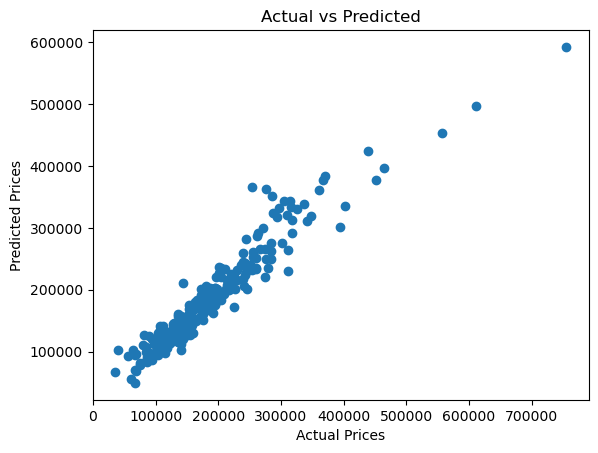

In [62]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

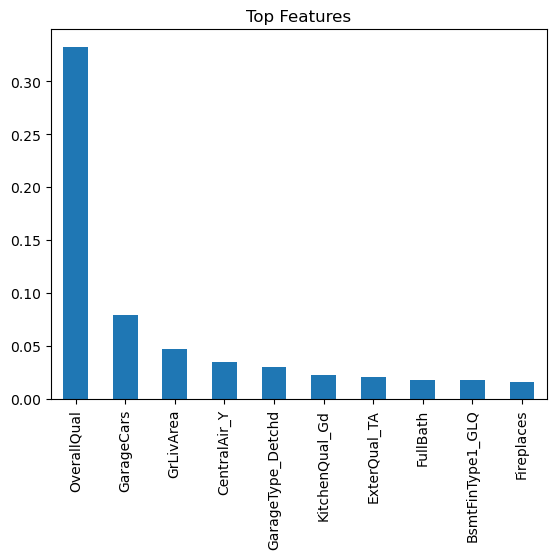

In [63]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Features")
plt.show()

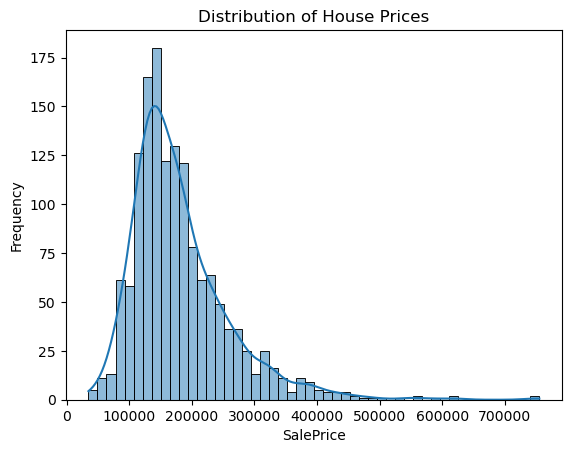

In [64]:
plt.figure()
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

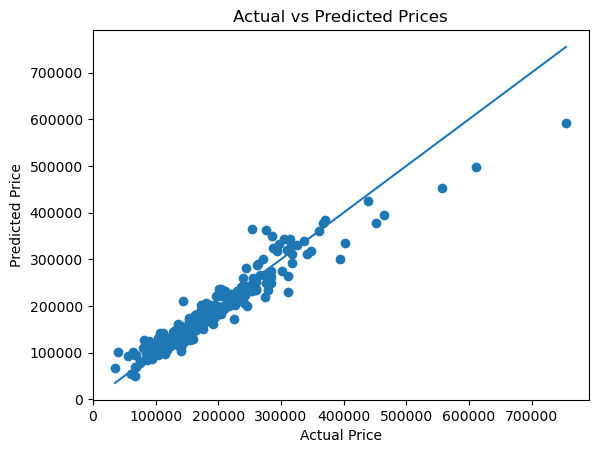

In [65]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

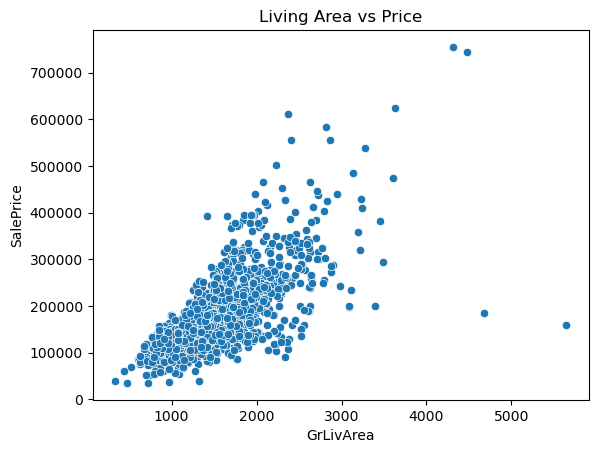

In [68]:
plt.figure()
sns.scatterplot(x=df["GrLivArea"], y=df["SalePrice"])
plt.title("Living Area vs Price")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.show()

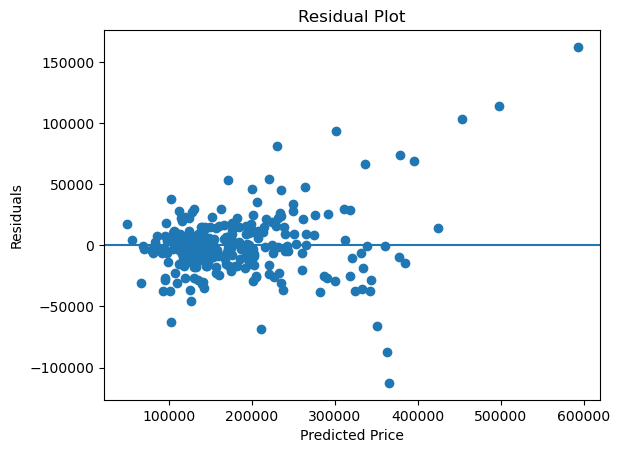

In [70]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Evaluating Training Data With Test Data

In [71]:
test = pd.read_csv(r"C:\Users\gs602\Downloads\test.csv")

In [72]:
train_id = df["Id"]
test_id = test["Id"]

In [73]:
y = df["SalePrice"]
df = df.drop("SalePrice", axis=1)

In [74]:
full_data = pd.concat([df, test], axis=0)

In [75]:
full_data = full_data.fillna(full_data.mean(numeric_only=True))

In [76]:
full_data = pd.get_dummies(full_data, drop_first=True)

In [78]:
X = full_data[:len(df)]
X_test = full_data[len(df):]

In [79]:


model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [80]:
y_pred = model.predict(X_test)

# Submission

In [81]:
submission = pd.DataFrame({
    "Id": test_id,
    "SalePrice": y_pred
})

submission.to_csv("submission.csv", index=False)